# Transformer Tekstigeneraattori

Työkirjassa rakennettiin yksinkertainen transformer-pohjainen kielimalli tekstin generointiin. Mallia koulutettiin valitulla tekstiaineoistolla (Jane Austenin romaanilla joka on tekijäoikeus lain alla vapaa), ja sen avulla tuotettiin uutta tekstiä.

Tekoälyä pääosin käytettiin tiedonhaussa.

Koodi on kirjoitettu opettajan esimerkin pohjalta ja tiedonhaun myötä tehty muutoksia.


Aineisto on myös riittävän suuri mallin kouluttamiseen sekä kirjoitus on tarpeeksi selkeä ja monipuolista.

Tässä on tarpeelliset importit sekä katsotaan Keras versioa.

In [1]:
# Cell 1: Setup and imports
import os
os.environ['KERAS_BACKEND'] = 'tensorflow'

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.13.2
Keras backend: tensorflow


## Datan esikäsittely

Tekstin esikäsittely sisältää tekstin pilkkomista, sanaston muodostamista sekä numeroiksi muuntoa, jonka lisäksi muodostettiin syöte - kohde -pareja tämän avulla malli oppii ennustamaan seuraavan sanan helpommin.

In [ ]:
# Cell 2: Load and prepare text data
# Load the Jane Austen text
with open('/content/sample_data/Persuasion_by_Jane_Austen.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()

print(f"Text length: {len(text)} characters")1
print(f"First 103 characters: {text[:103]}")

Text length: 464827 characters
First 103 characters: Persuasion


by Jane Austen

(1818)




Contents


 CHAPTER I.
 CHAPTER II.
 CHAPTER III.
 CHAPTER IV.



In [4]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'persuasion_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)

# Train SentencePiece model
vocab_size = 8000
model_prefix = 'persuasion_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>']
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "she was persuaded"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁she', '▁was', '▁persuaded']
Vocabulary size: 8000


In [5]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i+seq_length+1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 100517
Number of sequences: 100453
Input shape: (100453, 64)
Target shape: (100453, 64)


Funktio luo positional encodingin, jolla voi esittää sanojen sijainti vektorina, jonka avulla saadaan uniikki vektori jokaiselle sijainnille.

In [6]:
def get_positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return angle_rads


Tässä rakennetaan yksinkertaisen transformer mallin tekstille. Syöte muutetaan vektoreiksi embedding-kerroksella ja käytetään aiempaa funktioo positional encodingin lisäämiseen. Toistetaan useita transformer -lohkoja jossa malli katsoo aiempia sanoja ja dense kerros lopuksi ennustaa seuraavan tokenin.

In [7]:
embed_dim = 192
num_heads = 4
ff_dim = 384
num_layers = 2

inputs_layer = keras.Input(shape=(seq_length,))
x = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs_layer)

pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = x + pos_encoding

for _ in range(num_layers):
    attn = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=0.1
    )(x, x, use_causal_mask=True)

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attn)

    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])

    ffn_out = ffn(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_out)

outputs = keras.layers.Dense(sp.get_piece_size())(x)

model = keras.Model(inputs_layer, outputs)

Tässä mallia compiletään käyttämällä Adam optimisaatiota eli mallin oppimista säädetään sillä, loss mittaa kuinka väärin ennusteet menevät ja metrics seuraa kuinka usein ennuste on oikein. model.summary lopuksi tulostaa mallin rakenteen ja loppujen lopuksi tuli yhteensä yli 3,5 miljoonaa parametreja malliin.

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 192)   │  1,536,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 192)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 192)   │        384 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 192)   │    148,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 192)   │    148,032 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 192)   │        384 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64, 8000)  │  1,544,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,674,048 (14.02 MB)

 Trainable params: 3,674,048 (14.02 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_inputs,
    train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=128,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('persuasion_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 61s 76ms/step - accuracy: 0.0650 - loss: 6.8480 - val_accuracy: 0.0672 - val_loss: 6.2720 - learning_rate: 5.0000e-05
Epoch 2/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.0940 - loss: 6.0425 - val_accuracy: 0.1497 - val_loss: 5.4747 - learning_rate: 5.0000e-05
Epoch 3/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.1772 - loss: 5.1271 - val_accuracy: 0.1950 - val_loss: 4.8120 - learning_rate: 5.0000e-05
Epoch 4/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.2040 - loss: 4.6732 - val_accuracy: 0.2167 - val_loss: 4.4786 - learning_rate: 5.0000e-05
Epoch 5/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.2212 - loss: 4.4031 - val_accuracy: 0.2322 - val_loss: 4.2491 - learning_rate: 5.0000e-05
Epoch 6/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.2351 - loss: 4.1998 - val_accuracy: 0.2466 - val_loss: 4.0610 - learning_rate: 5.0000e-05
Epoch 7/100
628/628 ━━━━━━━━━━━━━━━━━━━━ 41s 6

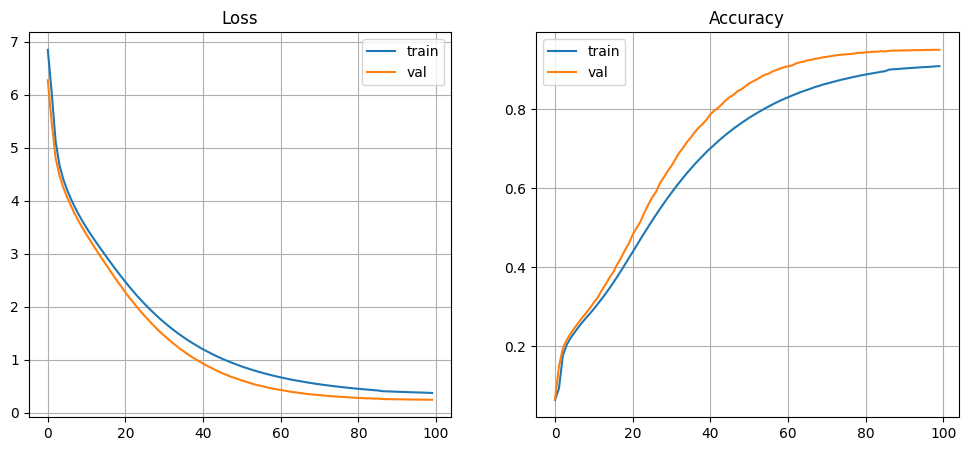

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()
plt.grid()

plt.show()

## Tarkkuus



In [11]:
model.save("persuasion_transformer.keras")
print("Model saved.")

Model saved.


In [15]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """
    Generate text autoregressively.

    Args:
        temperature: Controls randomness
            - Low (0.1-0.5): Focused, repetitive
            - Medium (0.7-1.0): Balanced
            - High (1.5+): Creative, chaotic
    """
    # Encode the prompt
    input_ids = sp.encode_as_ids(prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

Tässä luodaan tekstit ja annettiin promptit.

In [16]:
prompts = [
    "she was",
    "it was impossible",
    "mr elliot",
    "anne felt"
]

for prompt in prompts:
    print(f"\nPrompt: {prompt}")
    generated = generate_text(model, sp, prompt, num_tokens=100, temperature=1.2)
    print(generated)


Prompt: she was
she was, and yet was as desirous of saving Sir Walter’s feelings, as solicitous for the credit of the family, as aristocratic in her ideas of what was due to them, as anybody of sense and honesty could well be. She was a benevolent, charitable, good woman, and capable of strong attachments, most correct in her conduct, strict in her notions of decorum, and with manners that were held a standard of good-breeding. She had a cultivated mind, and was, generally speaking

Prompt: it was impossible
it was impossible; for in consequence of such great openness of conduct, such readiness to apologize for the past, such solicitude to be received as a relation again, that their former good understanding was completely re-established. They had not a fault to find in him. He had explained away all the appearance of neglect on his own side. It had originated in misapprehension entirely. He had never had an idea of throwing himself off; he had feared that he was thrown off, but knew 

## Analyysi

### Mallin tuottama teksti:

Hyvät puolet ovat kieliopillisesti usein oikein ja muistuttaa alkuperäistä tyyliä.


Huonot puolet ovat toisto sekä merkitys lähtee pidemmissä teksteissä, joten mallli toimii paremmin lyhyissä jaksoissa kuin pitkissä kokonaisuuksissa.

## Johtopäätökset

Transformer -malli pystyy oppimaan tekstin rakenteita ja tuottamaan uskottavaa tekstiä, mutta siinä on pidemmissä tekstipätkissä ongelmia. Pieni datasetti voi rajoittaa laatua, malli ei täysin ymmärrä merkityksiä eri sana yhdistelmissä sekä koulutus on hidasta.

### Yhteenveto

Transformer toimii hyvin tekstin generoinnissa, ja laatu paranee datan sekä mallin koon kasvaessa, mutta siinä menee pitkiä aikoja ja tarvii todella tehokkaat laitteet.